<a href="https://colab.research.google.com/github/Akshobhya07/Machine-Learning-Project/blob/main/ML_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier

In [1]:
from google.colab import files
uploaded = files.upload()

Saving day.csv to day.csv
Saving hour.csv to hour.csv


In [ ]:
df = pd.read_csv('/content/hour.csv')

In [ ]:
print(df.head())
print(df.isnull().sum())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
hol

In [ ]:
df['cnt'] = pd.cut(df['cnt'], bins=3, labels=[0,1,2])

In [ ]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [ ]:
X = df.drop(['cnt','instant','dteday','casual','registered'], axis=1)
y = df['cnt']
feature_names = X.columns

In [ ]:
df = pd.read_csv('/content/day.csv')

In [ ]:
print(df.head())
print(df.isnull().sum())


   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
instant       0
dteday    

In [ ]:
df['cnt'] = pd.cut(df['cnt'], bins=3, labels=[0,1,2])

In [ ]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop(['cnt','instant','dteday','casual','registered'], axis=1)
y = df['cnt']
feature_names = X.columns

In [ ]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train1)
X_test1 = scaler.transform(X_test1)

model = RandomForestClassifier()

model.fit(X_train1, y_train1)
y_pred1 = model.predict(X_test1)

print("\n===== 80:20 SPLIT =====")
print("Accuracy:", accuracy_score(y_test1, y_pred1))


===== 80:20 SPLIT =====
Accuracy: 0.8979591836734694


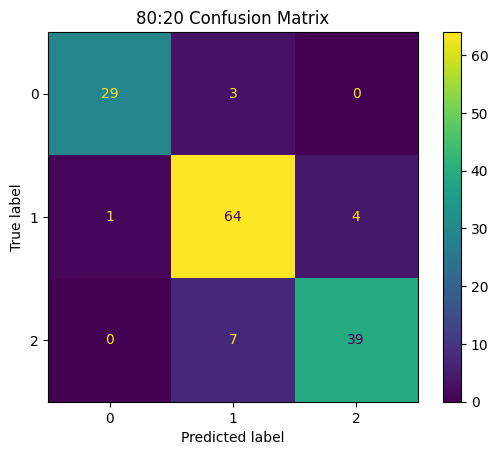

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_test1, y_pred1)).plot()
plt.title("80:20 Confusion Matrix")
plt.show()

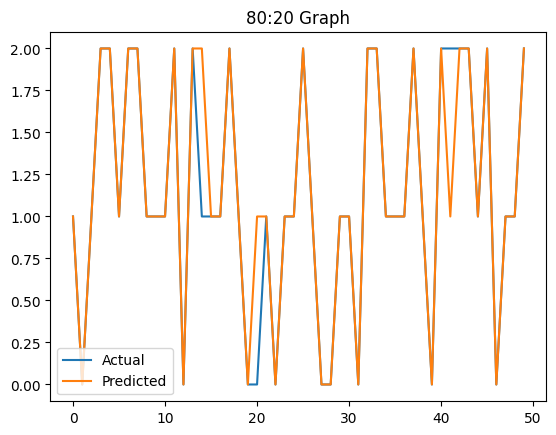

In [ ]:
plt.plot(y_test1.values[:50], label="Actual")
plt.plot(y_pred1[:50], label="Predicted")
plt.legend()
plt.title("80:20 Graph")
plt.show()

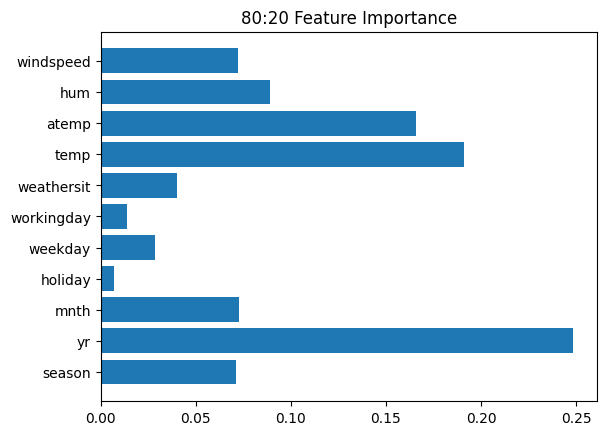

In [ ]:
if hasattr(model, "feature_importances_"):
    plt.barh(feature_names, model.feature_importances_)
    plt.title("80:20 Feature Importance")
    plt.show()

In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.3)

X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

model.fit(X_train2, y_train2)
y_pred2 = model.predict(X_test2)

print("\n===== 70:30 SPLIT =====")
print("Accuracy:", accuracy_score(y_test2, y_pred2))



===== 70:30 SPLIT =====
Accuracy: 0.9045454545454545


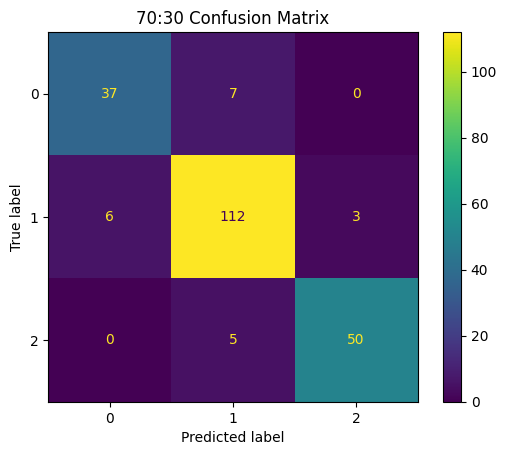

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_test2, y_pred2)).plot()
plt.title("70:30 Confusion Matrix")
plt.show()

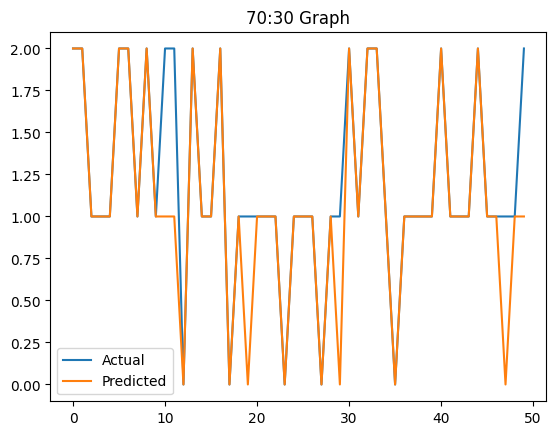

In [ ]:
plt.plot(y_test2.values[:50], label="Actual")
plt.plot(y_pred2[:50], label="Predicted")
plt.legend()
plt.title("70:30 Graph")
plt.show()

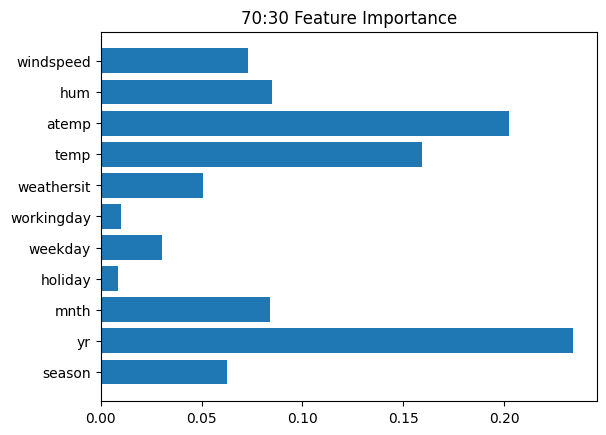

In [ ]:
if hasattr(model, "feature_importances_"):
    plt.barh(feature_names, model.feature_importances_)
    plt.title("70:30 Feature Importance")
    plt.show()

In [ ]:
X = df.drop('cnt', axis=1)
y = df['cnt']

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [4]:
model = RandomForestClassifier()
print("Model: RandomForestClassifier")

Model: RandomForestClassifier


===== 80:20 SPLIT =====
Accuracy  : 0.9524
Precision : 0.9526
Recall    : 0.9524
F1 Score  : 0.9522


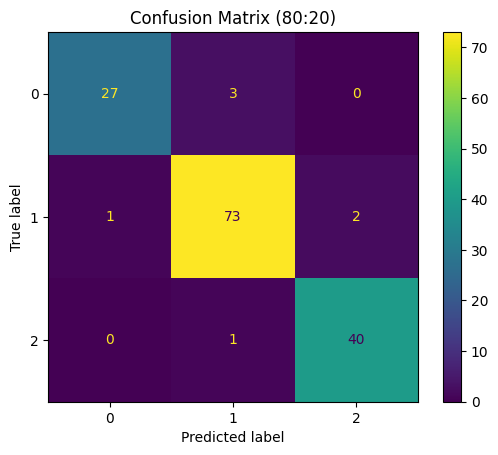

In [ ]:
# ==============================
# 80:20 SPLIT
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train1)
X_test1 = scaler.transform(X_test1)

model.fit(X_train1, y_train1)
y_pred1 = model.predict(X_test1)

print("===== 80:20 SPLIT =====")

acc1 = accuracy_score(y_test1, y_pred1)
prec1 = precision_score(y_test1, y_pred1, average='weighted')
rec1 = recall_score(y_test1, y_pred1, average='weighted')
f11 = f1_score(y_test1, y_pred1, average='weighted')

print(f"Accuracy  : {acc1:.4f}")
print(f"Precision : {prec1:.4f}")
print(f"Recall    : {rec1:.4f}")
print(f"F1 Score  : {f11:.4f}")

ConfusionMatrixDisplay(confusion_matrix(y_test1, y_pred1)).plot()
plt.title("Confusion Matrix (80:20)")
plt.show()

===== 70:30 SPLIT =====
Accuracy  : 0.9455
Precision : 0.9459
Recall    : 0.9455
F1 Score  : 0.9456


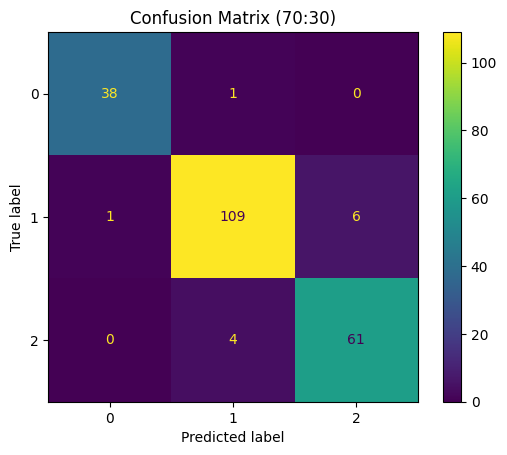

In [ ]:
# ==============================
# 70:30 SPLIT
# ==============================

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.3)

scaler = StandardScaler()
X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

model.fit(X_train2, y_train2)
y_pred2 = model.predict(X_test2)

print("===== 70:30 SPLIT =====")

acc2 = accuracy_score(y_test2, y_pred2)
prec2 = precision_score(y_test2, y_pred2, average='weighted')
rec2 = recall_score(y_test2, y_pred2, average='weighted')
f12 = f1_score(y_test2, y_pred2, average='weighted')

print(f"Accuracy  : {acc2:.4f}")
print(f"Precision : {prec2:.4f}")
print(f"Recall    : {rec2:.4f}")
print(f"F1 Score  : {f12:.4f}")

ConfusionMatrixDisplay(confusion_matrix(y_test2, y_pred2)).plot()
plt.title("Confusion Matrix (70:30)")
plt.show()

In [ ]:

import pandas as pd

comparison = pd.DataFrame({
    "Split": ["80:20", "70:30"],
    "Accuracy": [acc1, acc2],
    "Precision": [prec1, prec2],
    "Recall": [rec1, rec2],
    "F1 Score": [f11, f12]
})

print("\n📊 FINAL COMPARISON TABLE")
print(comparison)


📊 FINAL COMPARISON TABLE
   Split  Accuracy  Precision    Recall  F1 Score
0  80:20  0.952381   0.952572  0.952381  0.952190
1  70:30  0.945455   0.945870  0.945455  0.945562


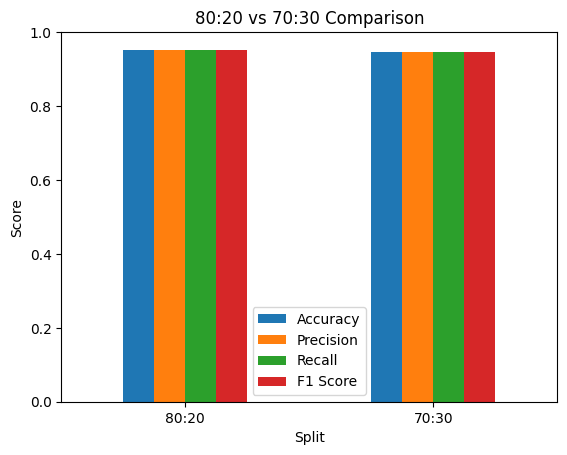

In [ ]:


comparison.set_index("Split").plot(kind='bar')

plt.title("80:20 vs 70:30 Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()